In [195]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef,
							accuracy_score, precision_score, recall_score, f1_score)

In [196]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")

In [ ]:
# To fill nulls
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 
train

,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,flow_pkts_per_sec,...,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,proto_icmp,proto_udp,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg,Attack_type
0,0.832746,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
1,0.715709,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
2,0.922972,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.250000,0.250000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
3,0.570230,0.000321,0.0,5.330092e-11,0.000282,0.000504,0.000282,0.0,1.000000,1.000000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
4,0.778759,0.093731,0.0,3.198055e-10,0.000282,0.000504,0.000000,0.0,0.160000,0.160000,...,0.015625,0.0,0.015625,0.0,0.0,2.0,2.000000,1.0,1.0,NMAP_OS_DETECTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98488,0.063005,0.000321,0.0,1.599028e-10,0.000282,0.000504,0.000282,0.0,0.307692,0.307692,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98489,0.117723,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98490,0.413428,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98491,0.126421,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping


In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 83)
Test shape: (24624, 83)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model

In [ ]:
# Multi class classification
label_encoder = LabelEncoder().fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values

Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


In [200]:
X_train

,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,flow_pkts_per_sec,...,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,proto_icmp,proto_udp,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg
0,0.832746,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
1,0.715709,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
2,0.922972,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.250000,0.250000,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
3,0.570230,0.000321,0.0,5.330092e-11,0.000282,0.000504,0.000282,0.0,1.000000,1.000000,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
4,0.778759,0.093731,0.0,3.198055e-10,0.000282,0.000504,0.000000,0.0,0.160000,0.160000,...,0.0,0.015625,0.0,0.015625,0.0,0.0,2.0,2.000000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98488,0.063005,0.000321,0.0,1.599028e-10,0.000282,0.000504,0.000282,0.0,0.307692,0.307692,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
98489,0.117723,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
98490,0.413428,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0
98491,0.126421,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.0,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0


In [ ]:
smote = SMOTENC(random_state=42,categorical_features=[2,76,77],sampling_strategy={0: np.rint(6200*1.2,).astype(int),
                                                                            1: np.rint(427*2).astype(int),
                                                                            2: np.rint(75727).astype(int),
                                                                            3: np.rint(3317*1.5).astype(int),
                                                                            4: np.rint(30*3).astype(int),
                                                                            5: np.rint(22*3).astype(int),
                                                                            6: np.rint(1600*1.75).astype(int),
                                                                            7: np.rint(802*2).astype(int),
                                                                            8: np.rint(2072*1.5).astype(int),
                                                                            9: np.rint(1608*1.75).astype(int),
                                                                            10: np.rint(6486*1.2).astype(int),
                                                                            11: np.rint(202*2).astype(int)})
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = X_train_res.values

In [224]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long) 

In [225]:
# X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)


from sklearn.utils.class_weight import compute_class_weight
w = torch.tensor(compute_class_weight(class_weight='balanced',classes=np.unique(y_train_res), y=y_train_res), dtype=torch.float)
print(w)


from sklearn.model_selection import StratifiedKFold

def make_stratified_dataloader(X, y, batch_size=64, n_splits=50):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    loaders = []
    for _, batch_id in skf.split(X, y):
        batch_dataset = TensorDataset(X[batch_id], y[batch_id])
        batch_loader = DataLoader(batch_dataset, batch_size=len(batch_id), shuffle=False)
        loaders.append(batch_loader)

    return loaders

train_loaders = make_stratified_dataloader(X_train_tensor,y_train_tensor, batch_size=64)




tensor([1.2059e+00, 1.0506e+01, 1.1848e-01, 1.8031e+00, 9.9691e+01, 1.3594e+02,
        3.2043e+00, 5.5936e+00, 2.8868e+00, 3.1884e+00, 1.1528e+00, 2.2208e+01])


In [226]:



# from torch.utils.data import WeightedRandomSampler
# y = np.array(y_train_res)
# class_counts = np.bincount(y)
# class_weights = 1.0 / class_counts
# sample_weights = class_weights[y]
# sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [205]:

class FocalLoss(nn.Module):
    def __init__(self, class_weights, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        # gather log_probs for the ground-truth classes
        targets_logp = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        targets_prob = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        loss = -self.class_weights[targets] * (1 - targets_prob) ** self.gamma * targets_logp


        if self.reduction == 'mean':
            return loss.mean()
        else:
            return loss


In [227]:
x = next(iter(train_loaders))
print(X_train_tensor.shape, X_test_tensor.shape)

torch.Size([107666, 82]) torch.Size([24624, 1, 82])


In [209]:
# input data format (batch_size, sequence_length, num_features)
# (batch, 1, 82) 
# the sequence represents temporal ordering...this would exist in real-time situation
class MultiClass1dCNN(nn.Module):
    def __init__(self, num_features=82, num_classes=12, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv1d(in_channels=1,out_channels=16,kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(in_channels=16,out_channels=32,kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*(num_features//2),256)
        self.fc2 = nn.Linear(256,128)
        self.dropout = nn.Dropout1d(.2)
        self.fc3 = nn.Linear(128,num_classes)

    def forward(self,x):
        # convolutions
        x = self.pool(F.relu(self.bn3(self.conv3(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))))))
        # dense layers
        # x = self.dropout(x)
        x = self.fc3(F.relu(self.fc2(self.dropout(F.relu(self.fc1((self.flatten(x))))))))
        # output
        return x

In [210]:
model = MultiClass1dCNN()

criterion = nn.CrossEntropyLoss()
criterion = FocalLoss(class_weights=w)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [231]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for loader in train_loaders:
        running_loss = 0.0
        total_loss = 0.0
        print("start epcoh")
        for xb, yb in loader:
            xb = xb.unsqueeze(1)  # (batch, 1, features)
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            running_loss += loss.item()
            total_loss+=loss.item()
            # if (batch+1) % 500 == 0:
            #     print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            #     running_loss = 0.0
        avg_loss = total_loss / len(loader)
        print(avg_loss)




# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     total_loss = 0.0
#     print("start epcoh")

#     for batch, (X_batch, y_batch) in enumerate(train_loader):
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         # loss = (loss*batch_weights).mean()

#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         running_loss += loss.item()
#         total_loss+=loss.item()

#         if (batch+1) % 500 == 0:
#             print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
#             running_loss = 0.0


#     avg_loss = total_loss / len(train_loader)
#     print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")

start epcoh
0.3609635829925537
start epcoh
0.35248932242393494
start epcoh
0.6420345306396484
start epcoh
0.3466552197933197
start epcoh
0.33837395906448364
start epcoh
0.5444417595863342
start epcoh
0.45339521765708923
start epcoh
0.5242234468460083
start epcoh
0.3252335786819458
start epcoh
0.3211647570133209
start epcoh
0.6820887923240662
start epcoh
0.5456615686416626
start epcoh
0.34955447912216187
start epcoh
0.43825316429138184
start epcoh
0.5800911784172058
start epcoh
0.5491695404052734
start epcoh
0.4729817509651184
start epcoh
0.5145360231399536
start epcoh
0.541723906993866
start epcoh
0.5507181882858276
start epcoh
0.45259833335876465
start epcoh
0.47728732228279114
start epcoh
0.510417103767395
start epcoh
0.4883739650249481
start epcoh
0.4043884873390198
start epcoh
0.4453493654727936
start epcoh
0.4865274131298065
start epcoh
0.5218456387519836
start epcoh
0.3909544050693512
start epcoh
0.498322993516922
start epcoh
0.6849056482315063
start epcoh
0.43845149874687195
sta

In [232]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 1425     2     0     2    60     2     0     0    40     0    18     1]
 [    0   106     0     0     1     0     0     0     0     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    2     1     0   824     0     0     0     0     2     0     0     0]
 [    0     0     0     0     7     0     0     0     0     0     0     0]
 [    0     0     0     0     1     0     0     0     5     0     0     0]
 [    0     0     0     0     0     0     0     0   400     0     0     0]
 [    0     0     0     0     0     0     0     0   200     0     0     0]
 [    1    24     0     0     4     0     0     0   489     0     0     0]
 [    1     0     0     0     1     0     0     0   400     0     0     0]
 [   84     2     0     0     5     0     0     0     3     0  1525     3]
 [    0     0     0     0     0     0     0     0     7     0     0    44]]
                            precision    recall  f1-score   support

            ARP_poisioning    

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
# model.eval()
all_preds = []
all_labels = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.softmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)
# print(confusion_matrix(all_labels, all_preds))
# print(classification_report(all_labels, all_preds, target_names=class_names))


In [188]:
thresholds = np.linspace(0.05, 0.95, 19)
best_thresholds = []

for i in range(12):
    f1s = []
    for t in thresholds:
        preds = (all_preds[:, i] > t).astype(int)
        true = (all_labels == i).astype(int)
        f1s.append(f1_score(true, preds))
    best_thresholds.append(thresholds[np.argmax(f1s)])

def predict_with_thresholds(probs, thresholds):
    preds = np.zeros(probs.shape[0], dtype=int)
    for idx, p in enumerate(probs):
        # pick class with prob above its threshold; fallback to argmax
        candidates = [i for i, prob in enumerate(p) if prob > thresholds[i]]
        if candidates:
            preds[idx] = candidates[np.argmax(p[candidates])]
        else:
            preds[idx] = np.argmax(p)
    return preds

val_preds = predict_with_thresholds(all_preds, best_thresholds)

# Optional: compute macro F1 after threshold tuning
macro_f1 = f1_score(all_labels, val_preds, average='macro')
print("Macro F1 after threshold tuning:", macro_f1)
print(best_thresholds)

Macro F1 after threshold tuning: 0.026186946111140644
[0.05, 0.1, 0.05, 0.05, 0.05, 0.15, 0.05, 0.05, 0.05, 0.05, 0.2, 0.95]


In [191]:
all_preds = val_preds
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.07      0.77      0.13      1550
            DDOS_Slowloris       1.00      0.02      0.04       107
             DOS_SYN_Hping       1.00      0.03      0.05     18932
              MQTT_Publish       1.00      0.02      0.04       829
Metasploit_Brute_Force_SSH       0.00      0.00      0.00         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.00      0.00      0.00       400
             NMAP_TCP_scan       0.01      0.17      0.01       200
             NMAP_UDP_SCAN       1.00      0.01      0.02       518
       NMAP_XMAS_TREE_SCAN       0.00      0.00      0.00       402
               Thing_Speak       0.02      0.02      0.02      1622
                Wipro_bulb       0.01      0.10      0.01        51

                  accuracy                           0.07     24624
                 macro

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

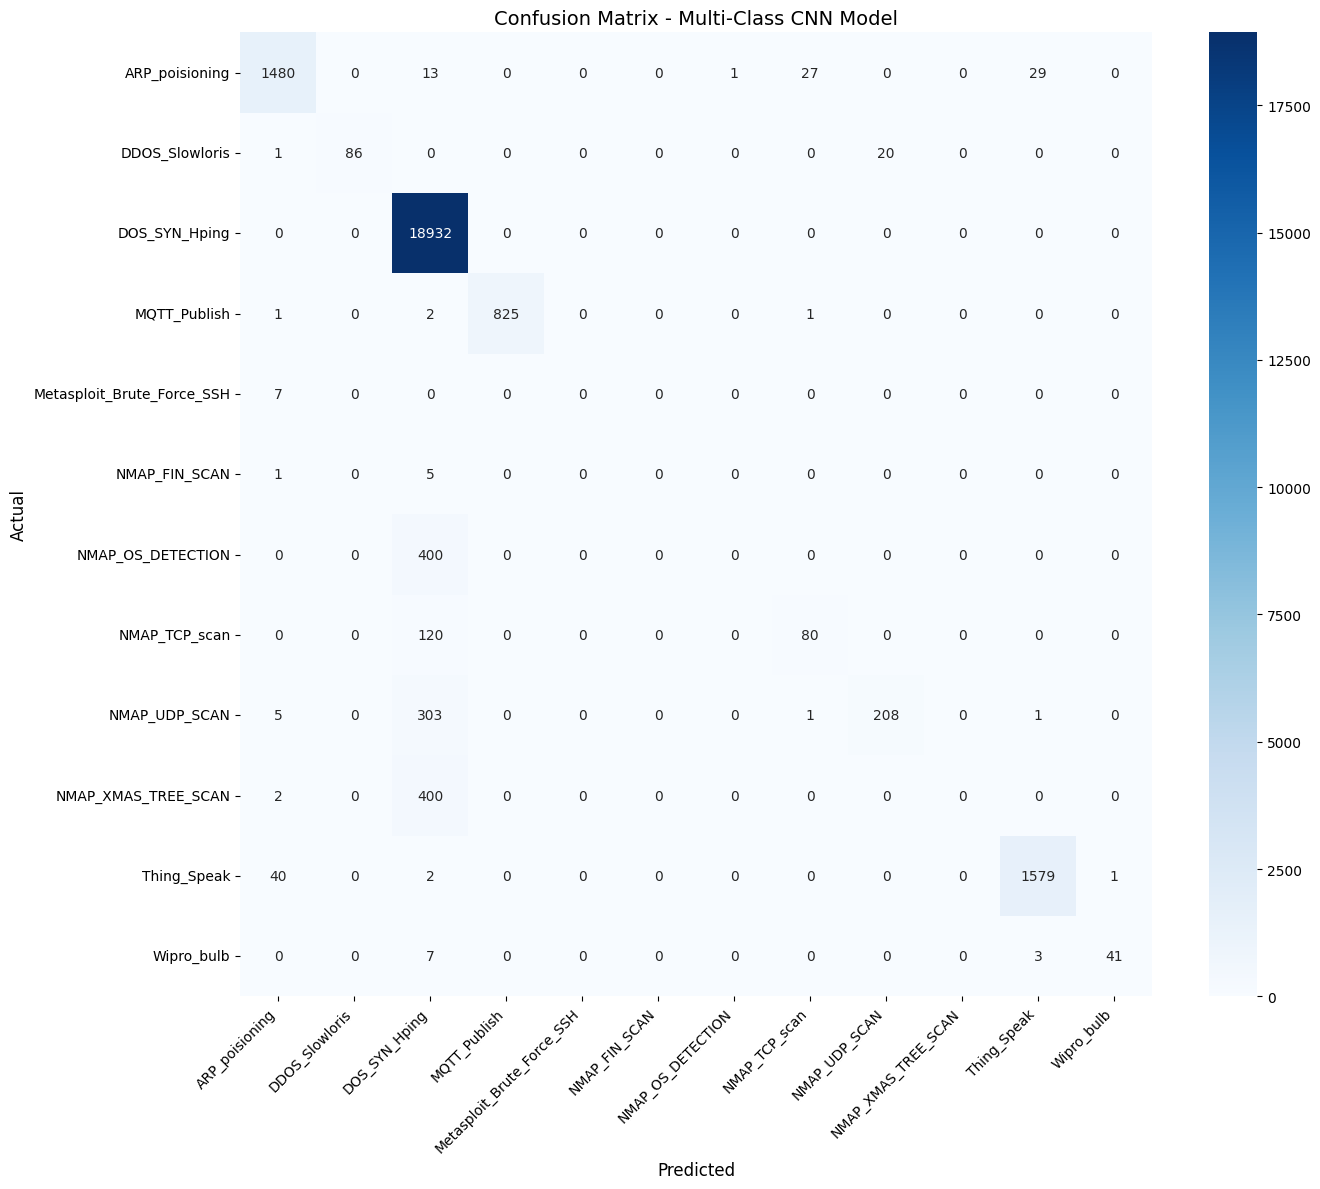

<Figure size 640x480 with 0 Axes>

In [24]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Multi-Class CNN Model", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("confusion_matrix.png", dpi=600, bbox_inches='tight')

In [52]:
torch.save(model.state_dict(), "models/1dcnn_multiclass.pth")
print("Model saved to models/1dcnn_multiclass.pth")

Model saved to models/1dcnn_multiclass.pth
